# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [1]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from shapely.wkt import loads
from shapely.ops import unary_union

from src.eda import (COLORS, COLORS_DICT, get_parks_data, groupby_multipoly,
                     PARKS_MAPPING, nymyc_cmap, nymyc_cmap_r, read_all_csvs,
                     remove_duplicate_obs, remove_unknown_sp)

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

<Axes: >

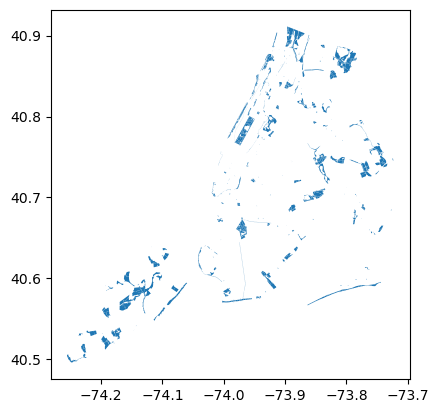

In [2]:
parks = gpd.read_file('../data/Parks Zones_20241027/', crs='epsg:4326', geometry='geometry')
parks.plot()

<Axes: >

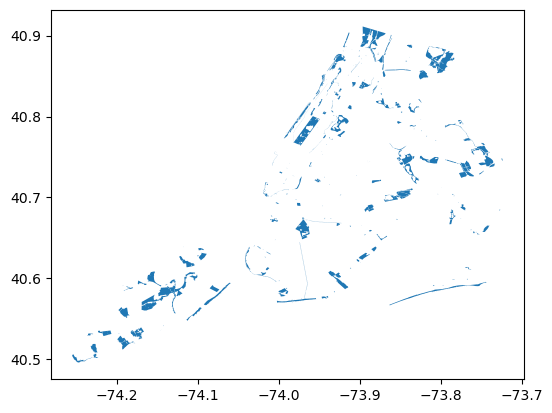

In [3]:
# https://stackoverflow.com/questions/73803944/convert-polygon-to-multi-polygon
# Need to do this to match the Multipolygons for Green-wood and Woodlawn Cemeteries
parks = parks.groupby(['propname','borough'], as_index=False)['geometry'].apply(unary_union)
parks.plot()

Got it plotting! But definitely need borough boundaries or something else in the background--can't just have parks floating in space.

<Axes: >

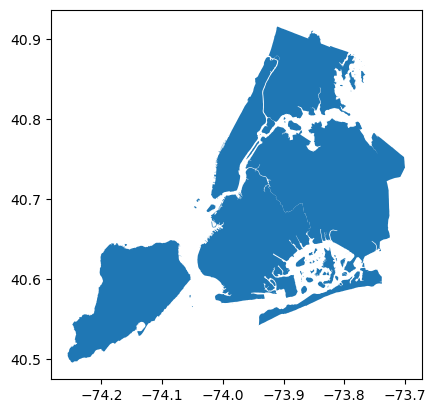

In [4]:
boroughs = gpd.read_file('../data/Borough Boundaries/')
boroughs.plot()

Now to combine them...

<Axes: >

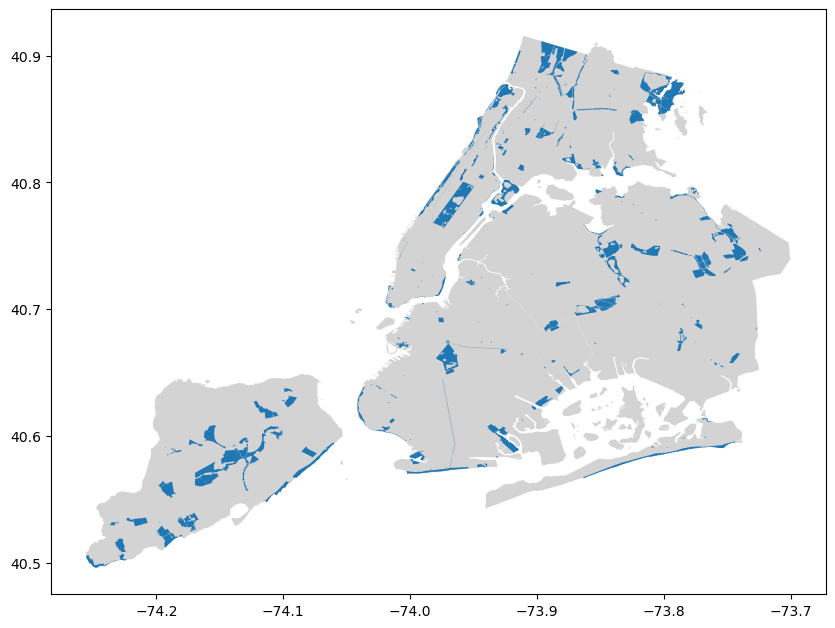

In [5]:
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Need to add in Green-Wood and Woodlawn Cemeteries.

In [6]:
cemeteries = pd.read_csv('../data/2020_Neighborhood_Tabulation_Areas__NTAs__20241127.csv')
cemeteries['the_geom'] = cemeteries['the_geom'].apply(loads)
cemeteries = gpd.GeoDataFrame(cemeteries, crs='epsg:4326', geometry='the_geom')
cemeteries = cemeteries.loc[(cemeteries['NTAName'] == 'Green-Wood Cemetery') | (cemeteries['NTAName'] == 'Woodlawn Cemetery')][['the_geom','BoroName','NTAName']]
cemeteries

,the_geom,BoroName,NTAName
25,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ...",Brooklyn,Green-Wood Cemetery
114,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ...",Bronx,Woodlawn Cemetery


In [7]:
# Prep cemeteries data to append to parks data
cemeteries['BoroName'] = cemeteries['BoroName'].map({v: k for k, v in PARKS_MAPPING.items()})
cemeteries = cemeteries.rename(columns={'BoroName':'borough', 'NTAName':'propname','the_geom':'geometry'})
cemeteries = cemeteries.set_geometry('geometry')
cemeteries

,geometry,borough,propname
25,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ...",B,Green-Wood Cemetery
114,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ...",X,Woodlawn Cemetery


<Axes: >

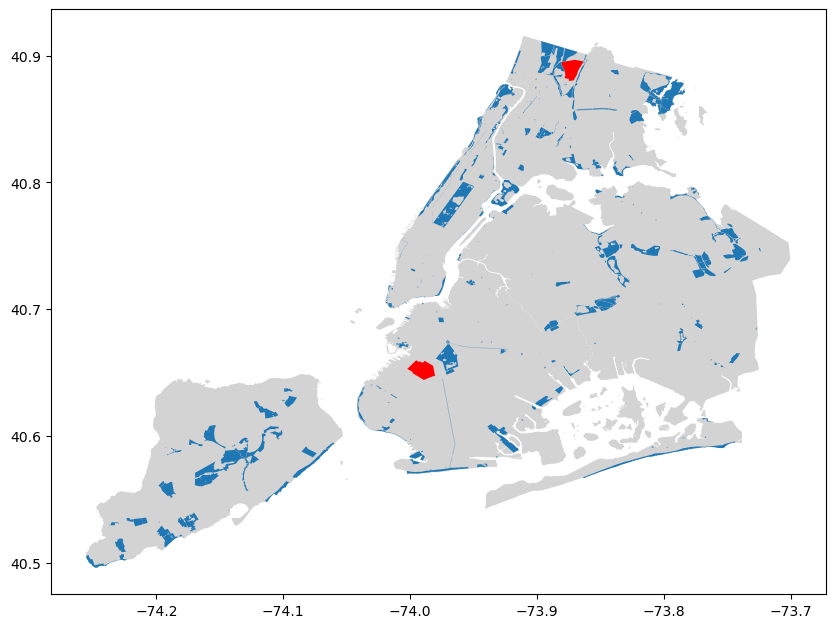

In [8]:
# Check that both cemeteries plot correctly
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
cemeteries.plot(ax=ax, color='red')
parks.plot(ax=ax)

In [9]:
parks = pd.concat([parks,cemeteries]).reset_index()
parks.tail()

,index,propname,borough,geometry
186,186,Washington's Walk,X,"MULTIPOLYGON (((-73.89832 40.87172, -73.89832 ..."
187,187,Williamsbridge Oval,X,"MULTIPOLYGON (((-73.87732 40.87671, -73.87734 ..."
188,188,Wolfe's Pond Park,R,"MULTIPOLYGON (((-74.18665 40.51804, -74.18665 ..."
189,25,Green-Wood Cemetery,B,"MULTIPOLYGON (((-73.98843 40.65925, -73.98623 ..."
190,114,Woodlawn Cemetery,X,"MULTIPOLYGON (((-73.87407 40.88004, -73.87495 ..."


<Axes: >

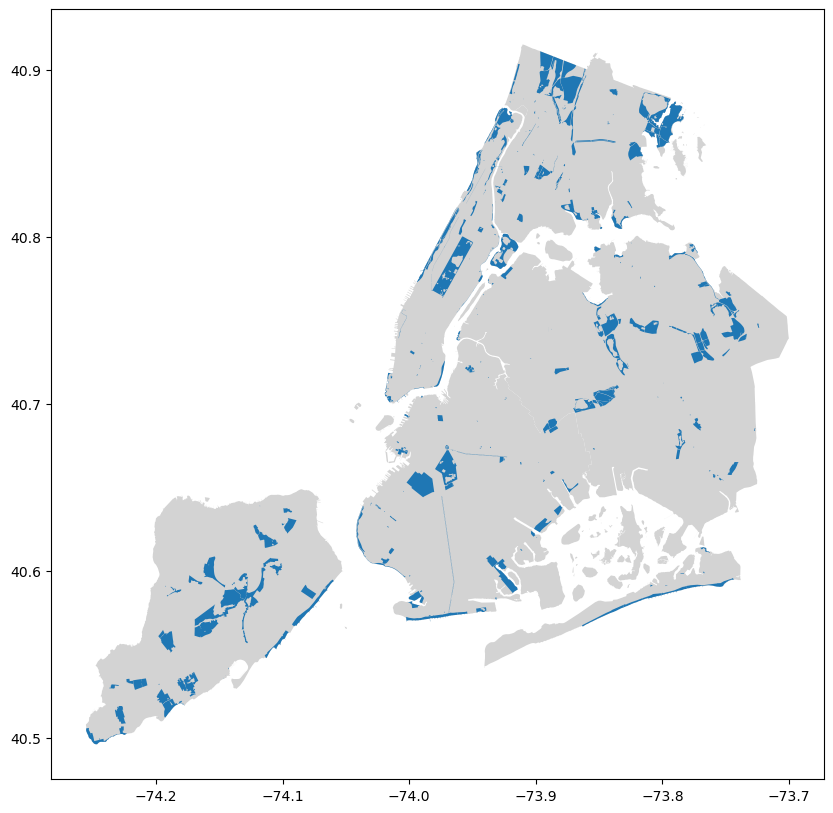

In [10]:
# Check that both cemeteries have been added correctly
fig, ax = plt.subplots(figsize = (10,10))
boroughs.plot(ax=ax, color='lightgrey')
parks.plot(ax=ax)

Success! Now to get some data in there...

In [11]:
parks_data = get_parks_data()
parks_data.head()

,MushroomID,WalkID,NewToPark,NewToCity,Notes,ParkName,Borough,City,State,BroadGroupID,Genus,Species,BroadGroupName,FullName
0,300,1,y,y,as Boletus campestris,Central Park,Manhattan,New York City,NY,3.0,Hortiboletus,campestris,Boletes,Hortiboletus campestris
1,2329,1,y,y,NaN,Central Park,Manhattan,New York City,NY,3.0,Boletus,subvelutipes-complex,Boletes,Boletus subvelutipes-complex
2,3,1,y,y,(Boletus) pulverulentus,Central Park,Manhattan,New York City,NY,3.0,Cyanoboletus,pulverulentus,Boletes,Cyanoboletus pulverulentus
3,4,1,y,y,NaN,Central Park,Manhattan,New York City,NY,3.0,Gyroporus,castaneus,Boletes,Gyroporus castaneus
4,5,1,y,y,NaN,Central Park,Manhattan,New York City,NY,3.0,Tylopilus,ferrugineus,Boletes,Tylopilus ferrugineus


In [12]:
# Check for parks that don't match across datasets
nymyc_parks = list(parks_data['ParkName'].unique())
nymyc_parks.sort()
nyc_parks = list(parks['propname'].unique())
nyc_parks.sort()
print('Parks in walks list but not in NYC data:')
print([p for p in nymyc_parks if p not in nyc_parks])
print('\n')
print('Parks in NYC data but not in walks list:')
print([p for p in nyc_parks if p not in nymyc_parks])

Parks in walks list but not in NYC data:
['Beech Brook', 'Collis P. Huntingdon Park', 'Depew Park', "Devil's Den Preserve", 'Fahnestock State Park', 'High Rock Park', 'Manitou Point Preserve', 'Mt. Lakes Park', 'Norvin Green State Forest', 'Putnam Memorial State Park', 'South Mountain Reservation', 'Stony Brook, Harriman', 'Stony Brook, Long Island', 'Tallman State Park', 'Untermeyer Gardens', 'Wawayanda State Park']


Parks in NYC data but not in walks list:
['Alley Athletic Playground', 'Aqueduct Walk', 'Archie Spigner Park', 'Arden Woods', 'Asphalt Green', 'Asser Levy Park', 'Astoria Park', 'Bailey Playground', 'Baisley Pond Park', 'Battery Park City', 'Bayswater Park', 'Belt Parkway/Shore Parkway', 'Bensonhurst Park', 'Betsy Head Park', 'Blood Root Valley', 'Bloomingdale Park', 'Blue Heron Park', 'Bowne Park', 'Breukelen Ballfields', 'Broadway Malls', 'Bronx Park', 'Bronx River Parkway', 'Brookfield Park', 'Brooklyn Bridge Park', 'Brookville Park', 'Brower Park', 'CPL. Thompson Par

Looks like most of the parks from the walk list that aren't in NYC's data are, in fact, not in NYC. So no worries there. Others aren't NYC parks, like Woodlawn Cemetery, but we've added those in ourselves.

The parks in NYC's data that aren't in the walks list are a lot of parks that just don't have walks (like Washington Sq Park).

There are some that just don't match up (like 'Randalls Island' vs 'Randall's Island Park' and 'Wolfe\\'s Pond Park' vs 'Wolfe's Pond Park'), so should clean those up. (Note: adding that to some of the cleaning functinality in `eda.py` that gets called whenever reading in the data.)

In [13]:
parks_counts = parks_data.groupby('ParkName')[['BroadGroupName','Species']].nunique().reset_index()
parks_counts = parks_counts.rename(columns={'BroadGroupName':'BroadGroupCounts',
                                            'Species':'SpeciesCounts'})
parks_counts

,ParkName,BroadGroupCounts,SpeciesCounts
0,Alley Pond Park,16,381
1,Beech Brook,17,386
2,Central Park,14,316
3,Clove Lakes Park,15,302
4,Collis P. Huntingdon Park,14,245
5,Conference House Park,2,2
6,Cunningham Park,15,364
7,Depew Park,12,185
8,Devil's Den Preserve,11,128
9,Fahnestock State Park,13,159


In [14]:
parks_viz = parks.merge(parks_counts, left_on='propname', right_on='ParkName', how='left')
# Drop non-NYC parks (no SpeciesCounts)
parks_viz = parks_viz.dropna(subset='SpeciesCounts')
parks_viz.head()

,index,propname,borough,geometry,ParkName,BroadGroupCounts,SpeciesCounts
1,1,Alley Pond Park,Q,"MULTIPOLYGON (((-73.73349 40.74083, -73.73350 ...",Alley Pond Park,16.0,381.0
32,32,Central Park,M,"MULTIPOLYGON (((-73.97354 40.76377, -73.97354 ...",Central Park,14.0,316.0
34,34,Clove Lakes Park,R,"MULTIPOLYGON (((-74.10576 40.61868, -74.10571 ...",Clove Lakes Park,15.0,302.0
39,39,Conference House Park,R,"MULTIPOLYGON (((-74.25035 40.49756, -74.25038 ...",Conference House Park,2.0,2.0
46,46,Cunningham Park,Q,"MULTIPOLYGON (((-73.77509 40.72521, -73.77513 ...",Cunningham Park,15.0,364.0


In [15]:
parks_viz.shape

(17, 7)

''

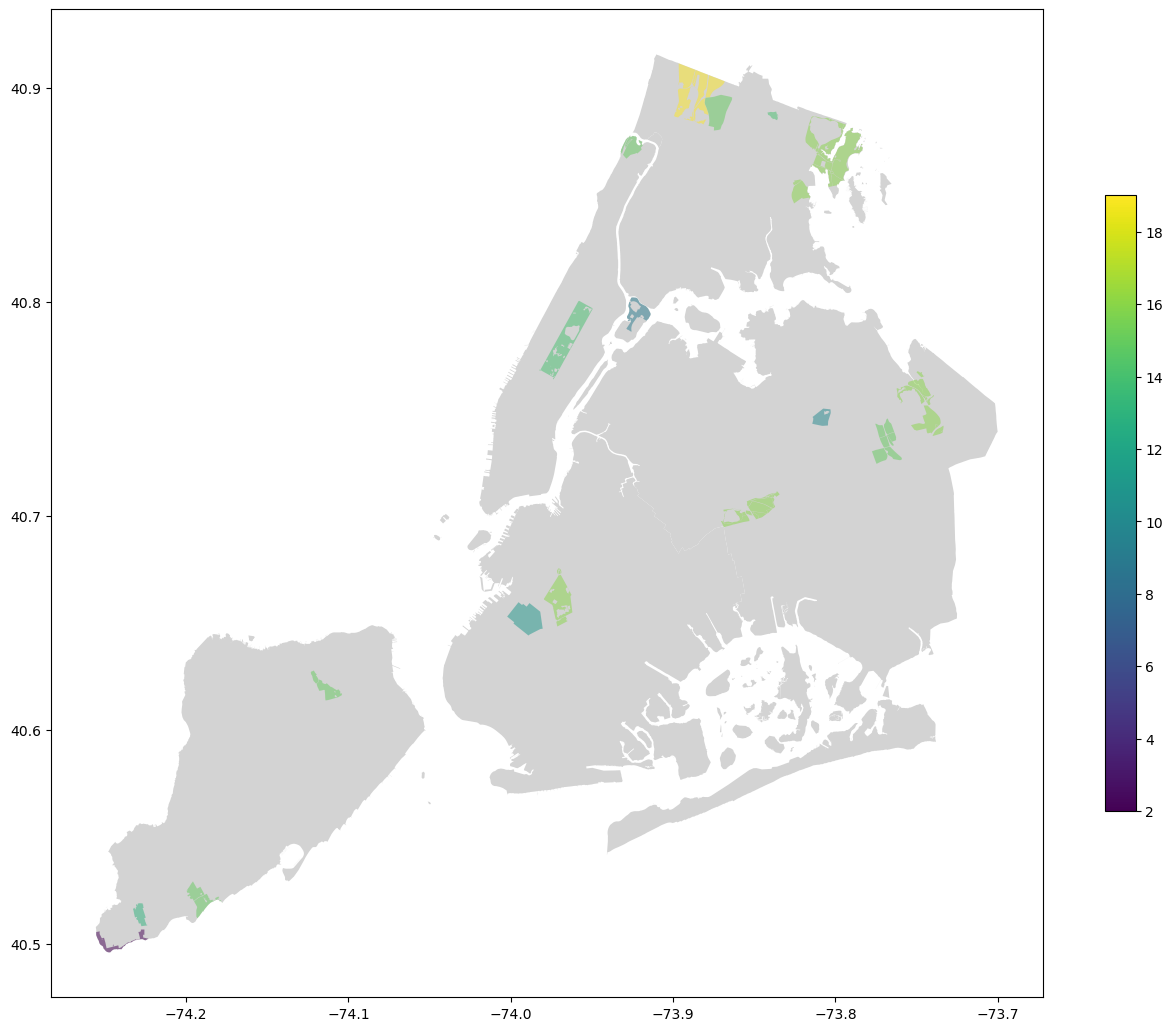

In [16]:
fig, ax = plt.subplots(figsize = (16,16))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='BroadGroupCounts', ax=ax,
                  legend=True, legend_kwds={"shrink":.5},
               alpha=.5)
plt.savefig('./img/parks_groups_counts.png')
;

''

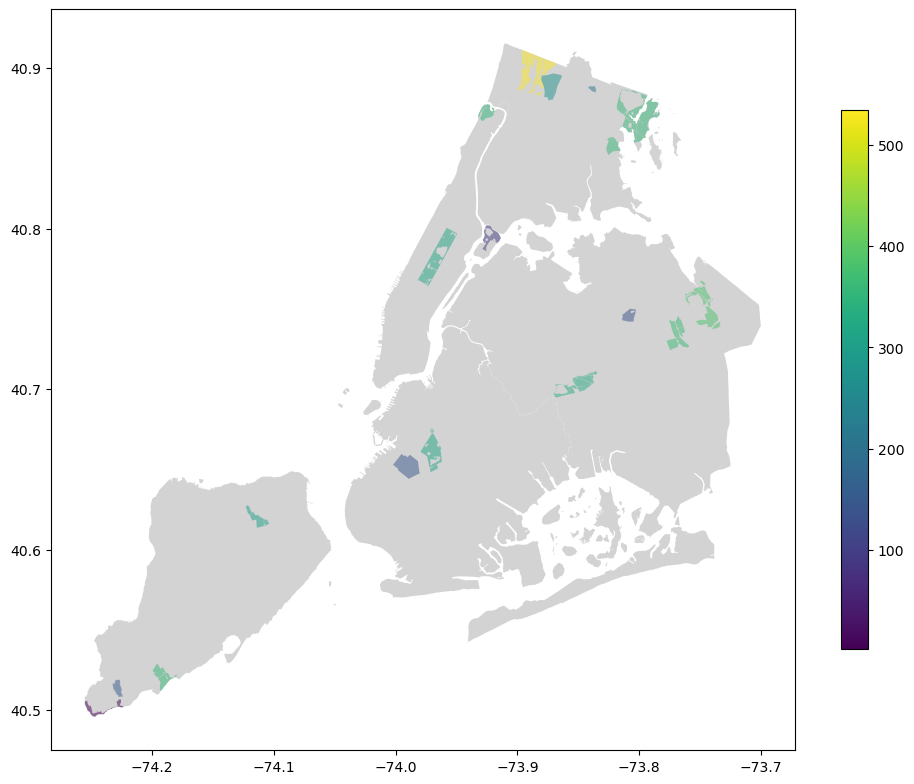

In [17]:
fig, ax = plt.subplots(figsize = (12,14))
boroughs.plot(ax=ax, color='lightgrey')
parks_viz.plot(column='SpeciesCounts', ax=ax,
               legend=True, legend_kwds={"shrink":.5},
               alpha=.5)
plt.savefig('./img/parks_species_counts.png')
;

Let's try visualizing each park separately to get better resolution.

''

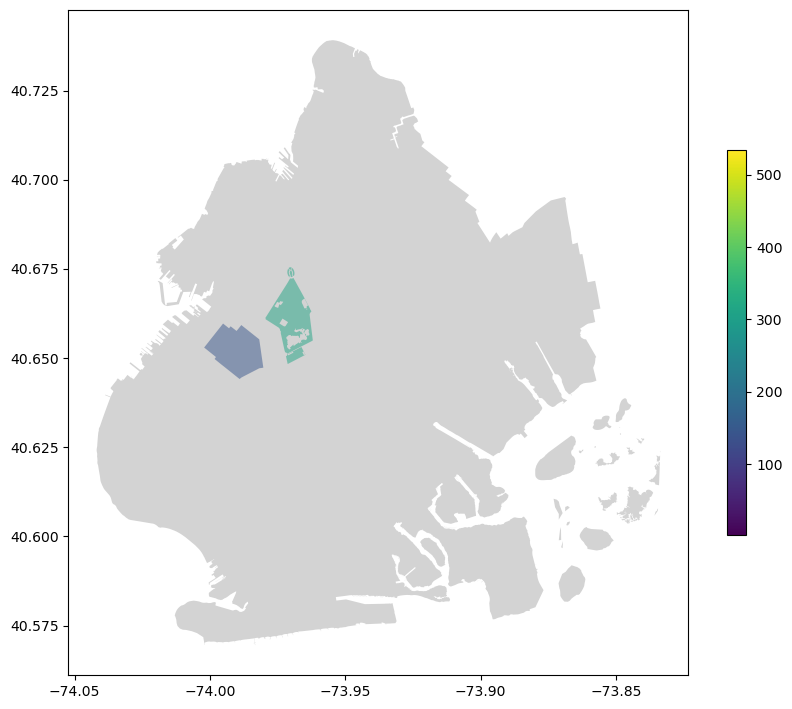

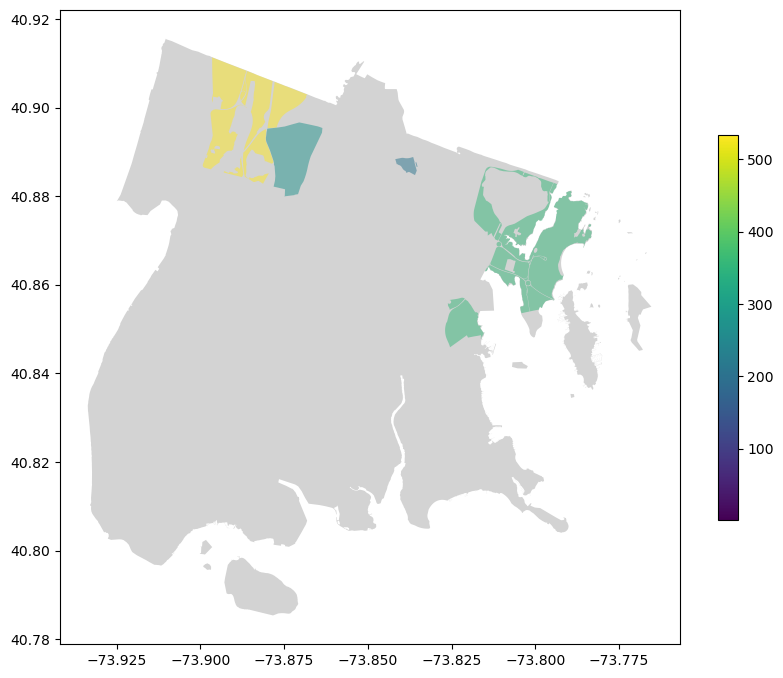

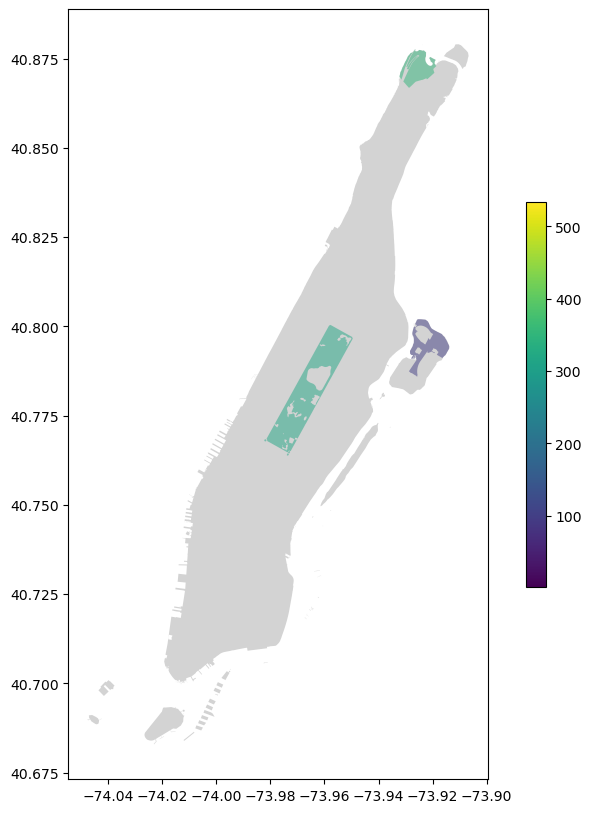

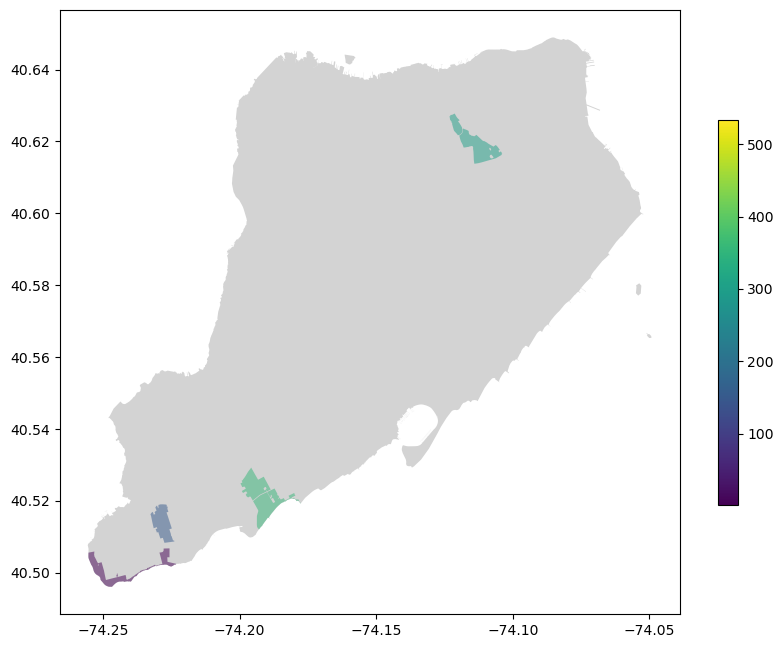

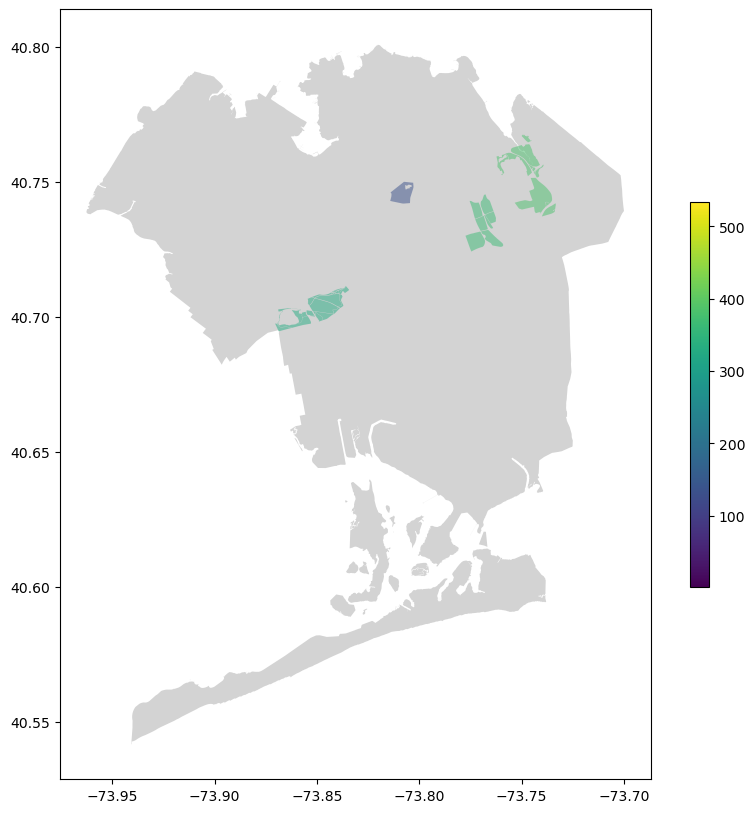

In [18]:
for b, boro in PARKS_MAPPING.items():
    fig, ax = plt.subplots(figsize=(10,10))
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax, legend=True, 
                                                legend_kwds={"shrink":.5}, alpha=.5, 
                                                vmin=parks_viz['SpeciesCounts'].min(),
                                                vmax=parks_viz['SpeciesCounts'].max())
;

''

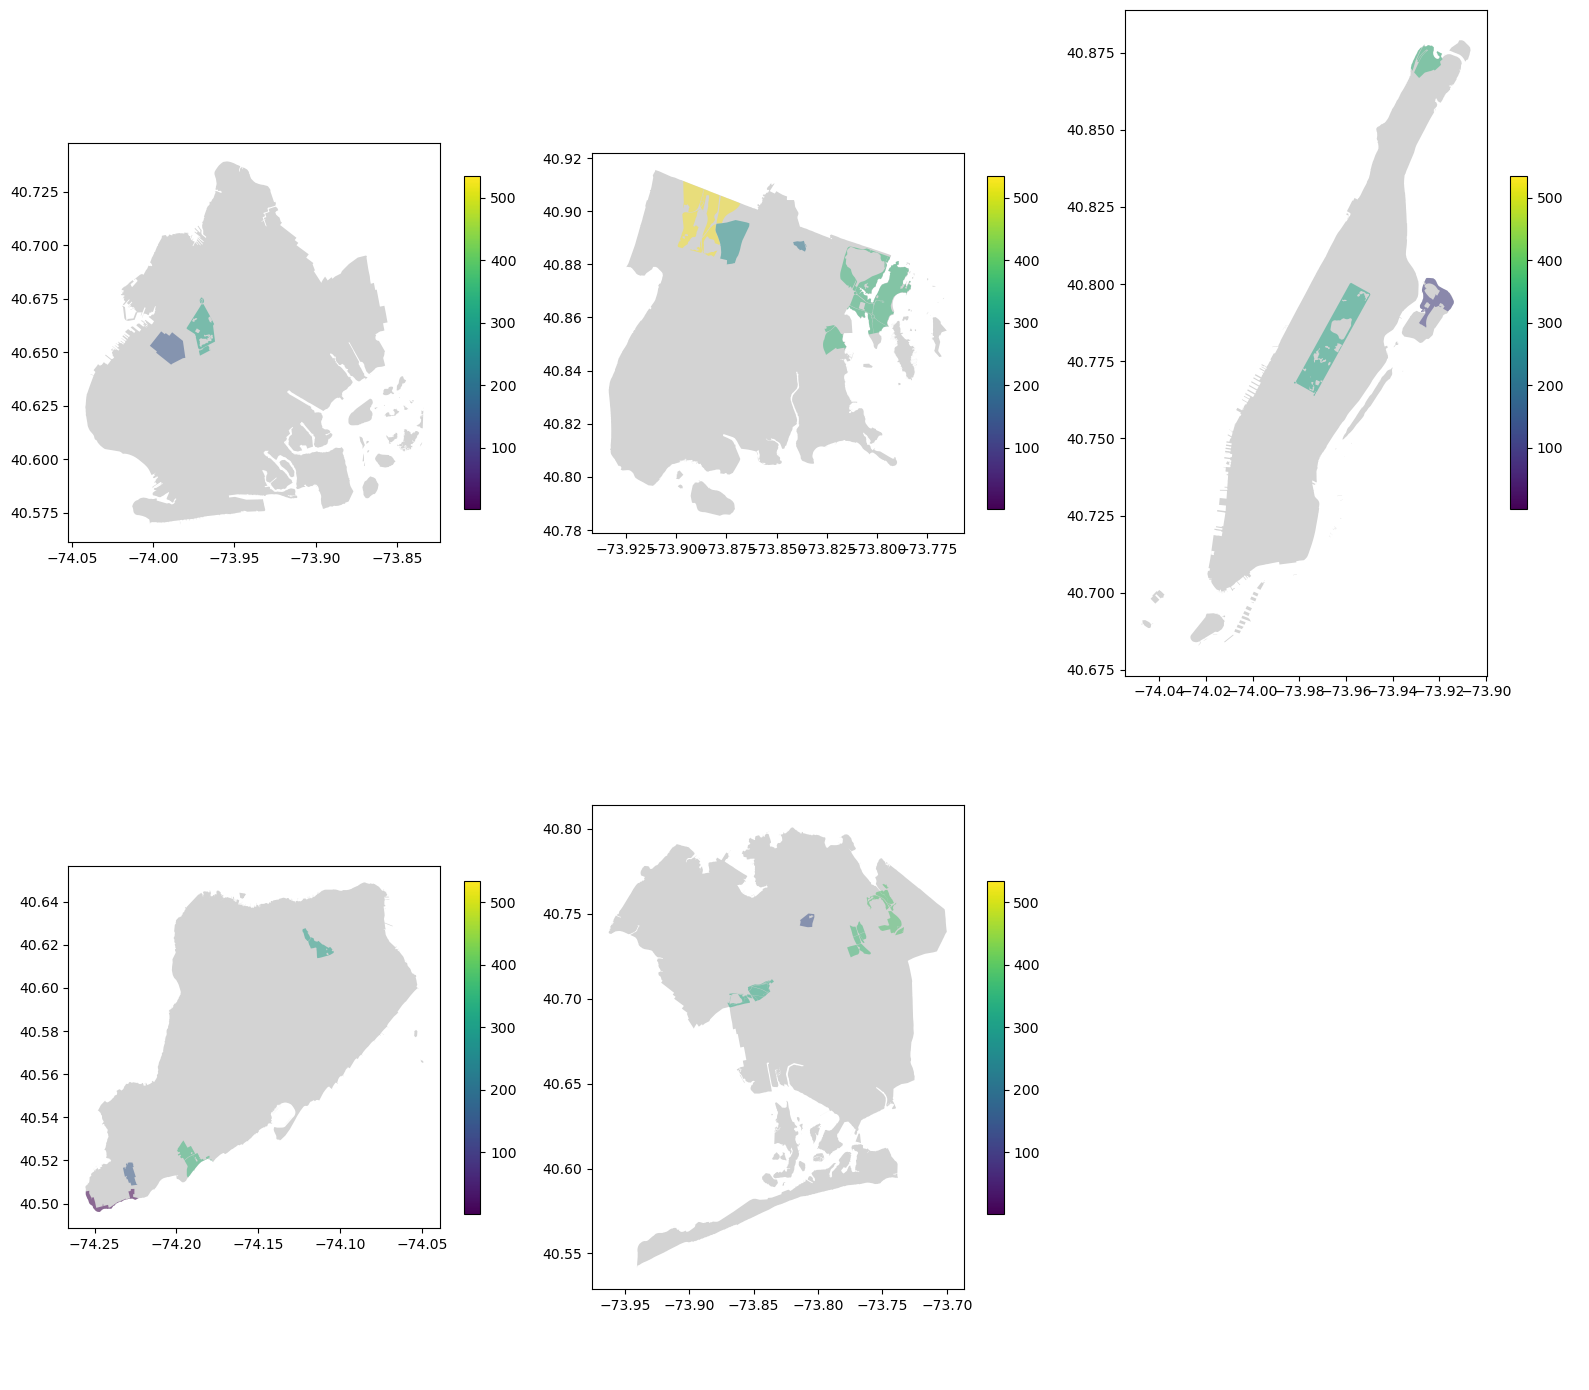

In [19]:
fig, axs = plt.subplots(2,3,figsize=(16,14))
axs = axs.ravel()
axs[-1].axis('off')
for ax, (b, boro) in zip(axs, PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='SpeciesCounts', ax=ax,
                                                legend=True, legend_kwds={"shrink":.5}, alpha=.5,
                                                vmin=parks_viz['SpeciesCounts'].min(),
                                                vmax=parks_viz['SpeciesCounts'].max())
plt.tight_layout()
;

In [20]:
boroughs.loc[boroughs['boro_name']=='Brooklyn']

,boro_code,boro_name,shape_area,shape_leng,geometry
0,3.0,Brooklyn,1.934143e+09,728147.130565,"MULTIPOLYGON (((-73.86327 40.58388, -73.86381 ..."


## Normalizing the data

Showing the number of species per park isn't super helpful since some parks are visited far more often than others. Let's try plotting the number of species *per walk*.

In [21]:
dfs = read_all_csvs('./data')
print(dfs.keys())

[*] Reading in Parks.csv...
[*] Reading in BroadGroups.csv...
[*] Reading in Parks_Properties_20241008.csv...
[*] Reading in 2020_Neighborhood_Tabulation_Areas__NTAs__20241127.csv...
[*] Reading in Mushroom.csv...
[*] Reading in Walks.csv...
[*] Reading in Observations.csv...
dict_keys(['parks', 'broadgroups', 'parks_properties_20241008', '2020_neighborhood_tabulation_areas__ntas__20241127', 'mushroom', 'walks', 'observations'])


In [22]:
remove_duplicate_obs(dfs['observations'])

,ObservationID,MushroomID,WalkID,ParkID,NewToPark,NewToCity,Notes,LinkToINat,DateCreated,DateModified
0,1,300,1,19,y,y,as Boletus campestris,NaN,2023-12-11 16:39:21,2023-12-11 16:39:21
1,2,2329,1,19,y,y,NaN,NaN,2023-12-13 21:15:44,2023-12-13 21:15:44
2,3,3,1,19,y,y,(Boletus) pulverulentus,NaN,2023-12-11 16:39:21,2023-12-11 16:39:21
3,4,4,1,19,y,y,NaN,NaN,2023-12-11 16:39:21,2023-12-11 16:39:21
4,5,5,1,19,y,y,NaN,NaN,2023-12-11 16:39:21,2023-12-11 16:39:21
...,...,...,...,...,...,...,...,...,...,...
35635,37176,3214,596,14,y,y,on Poaceae,NaN,2024-11-21 07:23:34,NaT
35636,37177,3120,596,14,y,NaN,Smilax rotundifolia,NaN,2024-11-21 07:23:34,NaT
35637,37178,3215,596,14,y,y,on Viola,NaN,2024-11-21 07:23:34,NaT
35638,37179,3192,596,14,y,NaN,on Prunus,NaN,2024-11-21 07:23:34,NaT


In [23]:
walk_counts = (remove_duplicate_obs(dfs['observations'])
               .groupby('WalkID')
               .agg({'MushroomID':'count','ParkID':'unique'})
               .reset_index()
               .rename(columns={'MushroomID':'SpeciesCount'})
              )
walk_counts['ParkID'] = walk_counts.apply(lambda x: x['ParkID'][0], axis=1)
walk_counts = walk_counts.merge(dfs['parks'][['ParkID','ParkName']], on='ParkID')
walk_counts.head()

,WalkID,SpeciesCount,ParkID,ParkName
0,1,42,19,Central Park
1,2,10,11,Pelham Bay Park
2,3,29,20,Clove Lakes Park
3,4,22,19,Central Park
4,5,27,21,"Stony Brook, Long Island"


In [24]:
parks_counts = walk_counts.groupby('ParkName').agg(TotalObservations=('SpeciesCount', 'sum'),
                                                   AvgSpeciesPerWalk=('SpeciesCount', 'mean'),
                                                   TotalWalks=('WalkID', 'nunique'),
                                                  ).round(2).reset_index()
parks_counts

,ParkName,TotalObservations,AvgSpeciesPerWalk,TotalWalks
0,Alley Pond Park,2102,84.08,25
1,Beech Brook,1127,140.88,8
2,Central Park,2138,49.72,43
3,Clove Lakes Park,1323,69.63,19
4,Collis P. Huntingdon Park,436,109.00,4
5,Conference House Park,2,1.00,2
6,Cunningham Park,2549,68.89,37
7,Depew Park,307,76.75,4
8,Devil's Den Preserve,145,145.00,1
9,Fahnestock State Park,240,120.00,2


In [25]:
# parks_counts = parks_data.groupby('ParkName')[['BroadGroupName','Species']].nunique().reset_index()
# parks_counts = parks_counts.rename(columns={'BroadGroupName':'UniqueBroadGroupCounts',
#                                             'Species':'UniqueSpeciesCounts'})
# parks_counts = parks_counts.merge(walk_counts, on='ParkName')
# parks_counts

In [26]:
# (parks_counts
#  .groupby('ParkName')
#  .agg(TotalSpeciesCount=('TotalSpeciesCount', 'sum'),
#        TotalSpeciesAvg=('TotalSpeciesCount', 'mean'),
#        UniqueBroadGroupCounts=('UniqueBroadGroupCounts','mean'),
#        UniqueSpeciesCounts=('UniqueSpeciesCounts','mean')
#       )
#  .round(2)
# ).reset_index()

In [27]:
parks_viz.head()

,index,propname,borough,geometry,ParkName,BroadGroupCounts,SpeciesCounts
1,1,Alley Pond Park,Q,"MULTIPOLYGON (((-73.73349 40.74083, -73.73350 ...",Alley Pond Park,16.0,381.0
32,32,Central Park,M,"MULTIPOLYGON (((-73.97354 40.76377, -73.97354 ...",Central Park,14.0,316.0
34,34,Clove Lakes Park,R,"MULTIPOLYGON (((-74.10576 40.61868, -74.10571 ...",Clove Lakes Park,15.0,302.0
39,39,Conference House Park,R,"MULTIPOLYGON (((-74.25035 40.49756, -74.25038 ...",Conference House Park,2.0,2.0
46,46,Cunningham Park,Q,"MULTIPOLYGON (((-73.77509 40.72521, -73.77513 ...",Cunningham Park,15.0,364.0


In [28]:
parks_viz = parks_viz.merge(parks_counts, on='ParkName')
parks_viz.head()

,index,propname,borough,geometry,ParkName,BroadGroupCounts,SpeciesCounts,TotalObservations,AvgSpeciesPerWalk,TotalWalks
0,1,Alley Pond Park,Q,"MULTIPOLYGON (((-73.73349 40.74083, -73.73350 ...",Alley Pond Park,16.0,381.0,2102,84.08,25
1,32,Central Park,M,"MULTIPOLYGON (((-73.97354 40.76377, -73.97354 ...",Central Park,14.0,316.0,2138,49.72,43
2,34,Clove Lakes Park,R,"MULTIPOLYGON (((-74.10576 40.61868, -74.10571 ...",Clove Lakes Park,15.0,302.0,1323,69.63,19
3,39,Conference House Park,R,"MULTIPOLYGON (((-74.25035 40.49756, -74.25038 ...",Conference House Park,2.0,2.0,2,1.00,2
4,46,Cunningham Park,Q,"MULTIPOLYGON (((-73.77509 40.72521, -73.77513 ...",Cunningham Park,15.0,364.0,2549,68.89,37


''

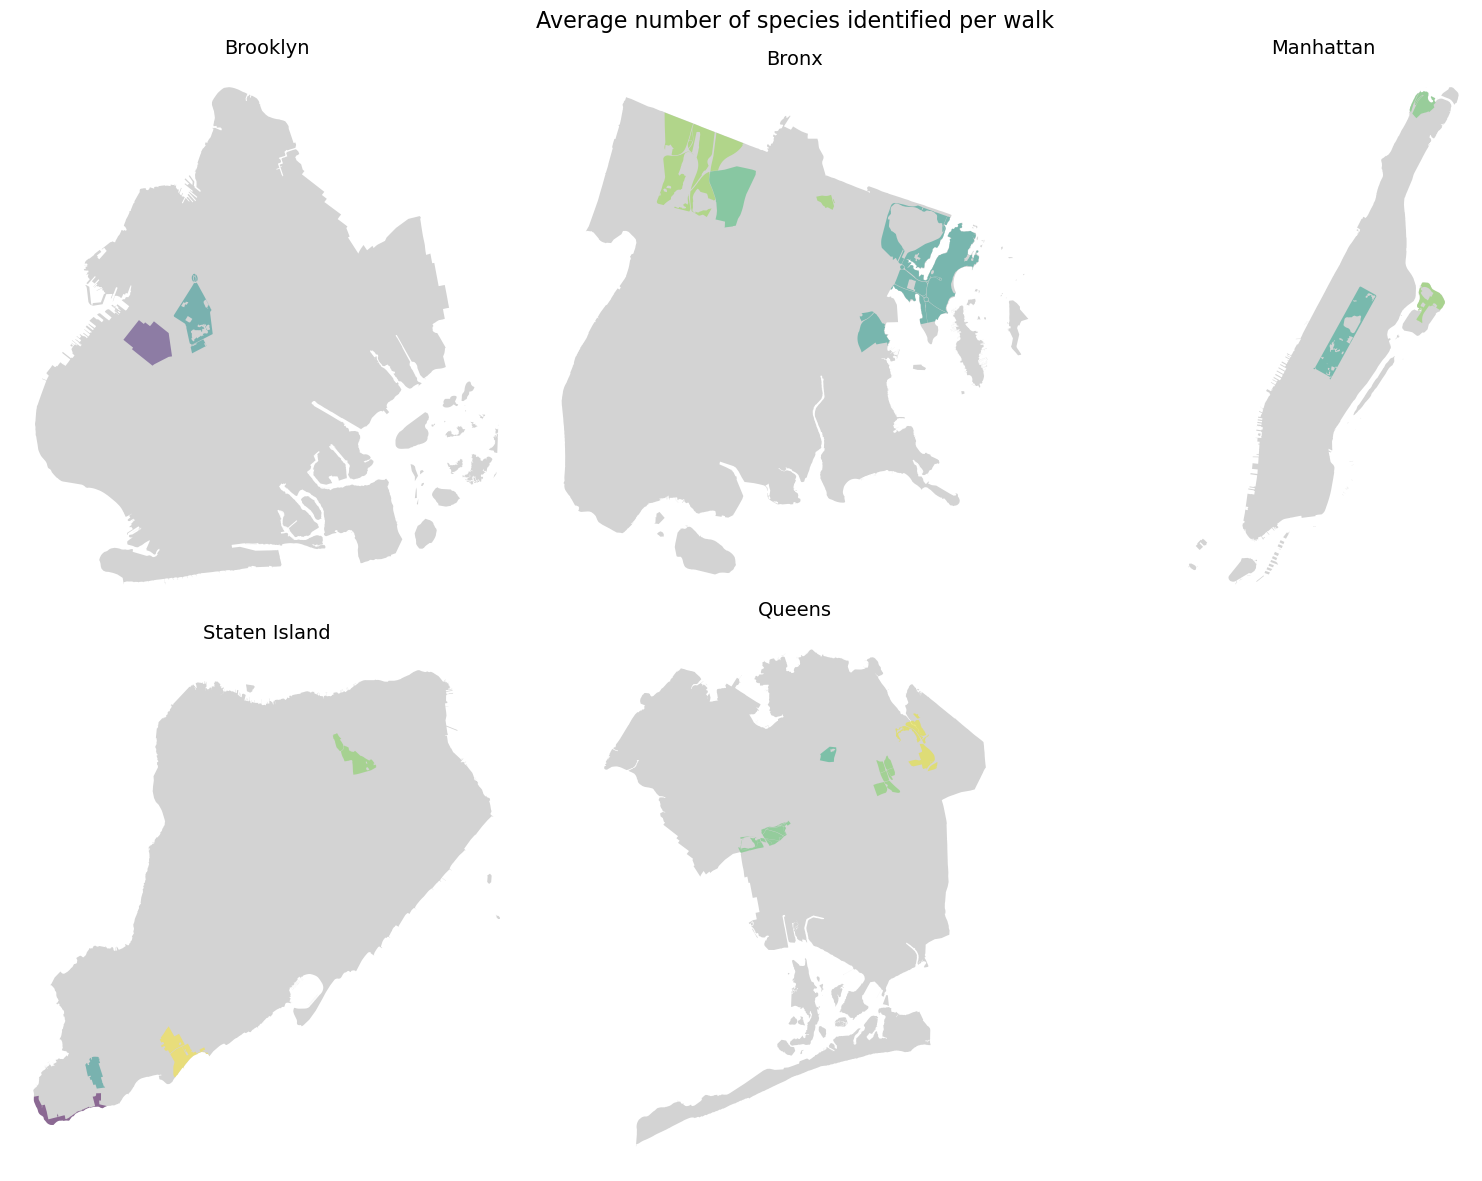

In [29]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='AvgSpeciesPerWalk', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['AvgSpeciesPerWalk'].min(),
                                                vmax=parks_viz['AvgSpeciesPerWalk'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Average number of species identified per walk', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_species_per_walk.png')
;

''

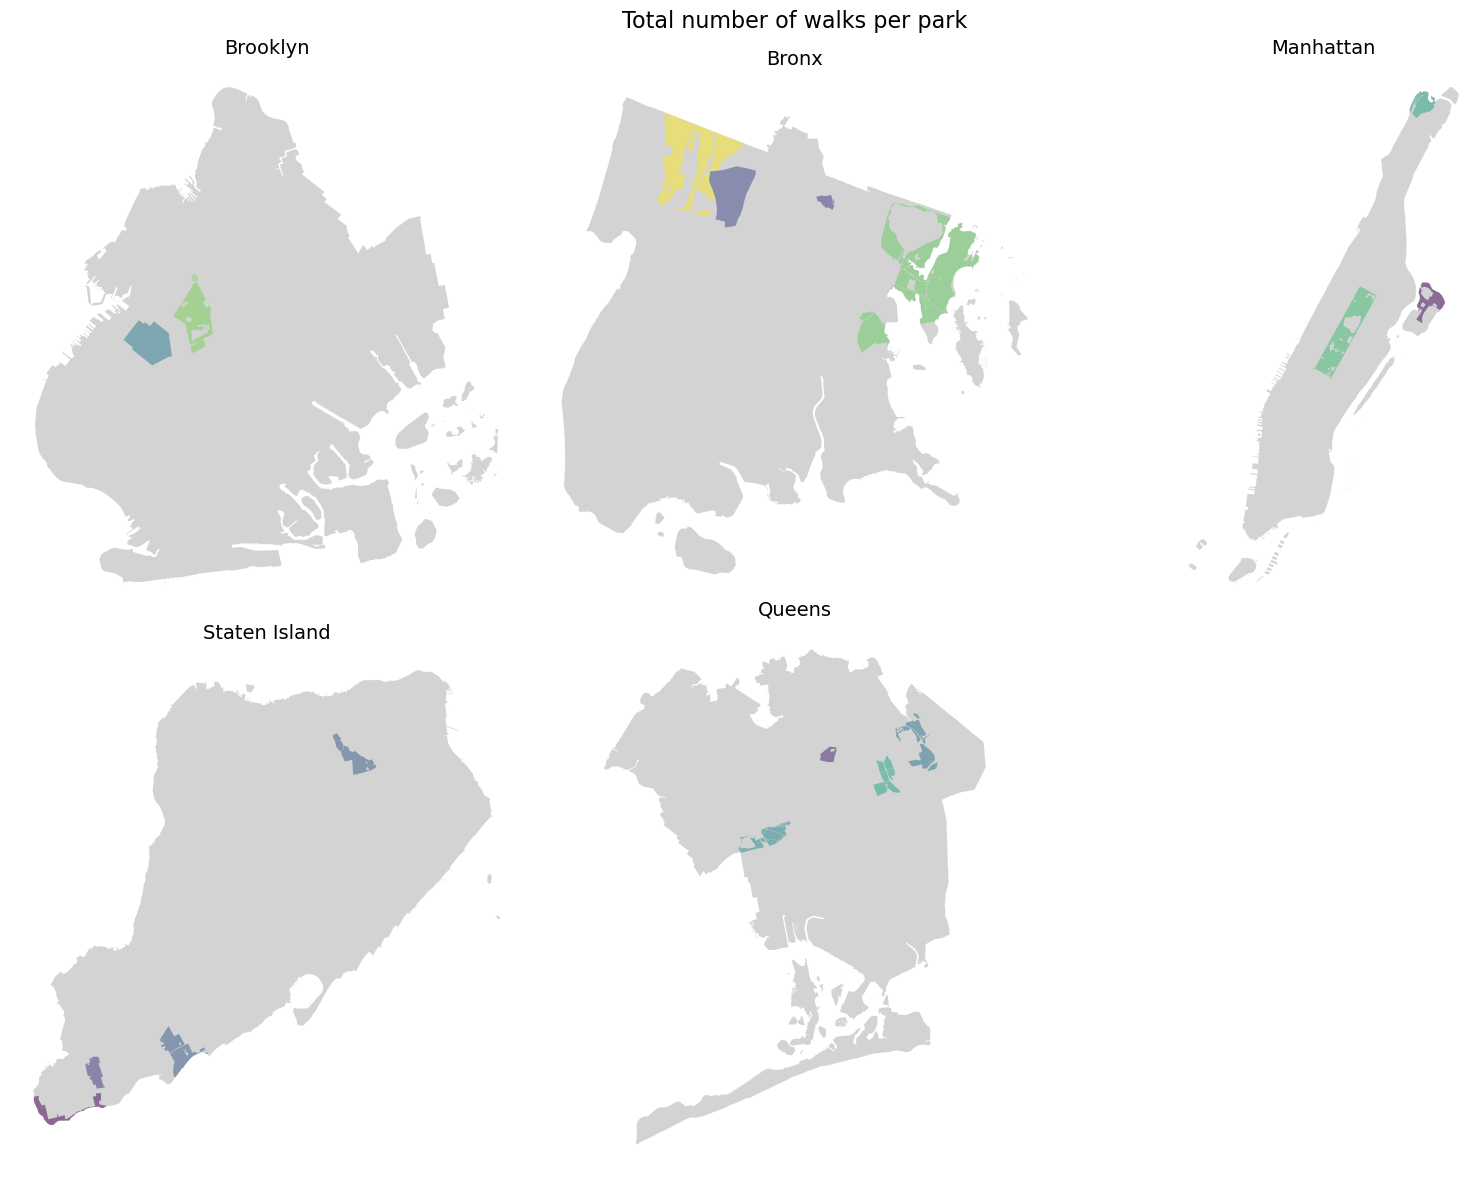

In [31]:
fig, axs = plt.subplots(2,3,figsize=(16,12))
for ax, (b, boro) in zip(axs.ravel(), PARKS_MAPPING.items()):
    boroughs.loc[boroughs['boro_name']==boro].plot(ax=ax, color='lightgrey')
    parks_viz.loc[parks_viz['borough']==b].plot(column='TotalWalks', ax=ax,
                                                legend=False, alpha=.5, 
                                                vmin=parks_viz['TotalWalks'].min(),
                                                vmax=parks_viz['TotalWalks'].max())
    ax.set_title(boro, fontsize=14)
    ax.set_axis_off()
axs[1][2].remove()
plt.suptitle('Total number of walks per park', fontsize=16)
plt.tight_layout()
plt.savefig('./img/parks_walks_per_park.png')
;